In [1]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

print("Path to dataset files:", path)
print("Files:", os.listdir(path))

import sqlite3
import pandas as pd

file_path = os.path.join(path, "Churn_Modelling.csv")  # adjust if needed

# Load data
df = pd.read_csv(file_path)

conn = sqlite3.connect("churn.db")
df.to_sql("customers", conn, if_exists="replace", index=False)

df_sql = pd.read_sql("SELECT * FROM customers", conn)

/Users/hasanbay/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Path to dataset files: /Users/hasanbay/.cache/kagglehub/datasets/rjmanoj/credit-card-customer-churn-prediction/versions/1
Files: ['Churn_Modelling.csv']


In [2]:

print(df.info())
print("Look here:")
print(df["Exited"].value_counts())#number of customers exited and stayed

print(df.groupby("Geography")["Exited"].mean())
print(df.groupby("Gender")["Exited"].mean())
print(df.groupby("Exited")["Age"].mean())

print("Hypothesis--German people are less in need of credit due to their better financial conditions:")
print(df.groupby("Geography")[["Balance", "IsActiveMember", "NumOfProducts"]].mean())

print("Does higher balance → higher churn?")

df["is_zero_balance"] = (df["Balance"] == 0)
print(df.groupby("is_zero_balance")["Exited"].mean())
df_nonzero = df[df["Balance"] > 0]

print(df_nonzero.groupby(pd.qcut(df_nonzero["Balance"], 4))["Exited"].mean())
print("Check whether higher balance -> higher churn:")
table = df.groupby(#df.groupby(["Geography", pd.qcut(df["Balance"], 4, duplicates="drop")])["Exited"].mean()
    ["Geography", pd.qcut(df["Balance"], 4, duplicates="drop")]
)["Exited"].mean().unstack()

print(table)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
Look here:
Exited
0    7963
1    2037
Name: count, dtype: int64
Geography
France     0.16

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/2355690099.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_nonzero.groupby(pd.qcut(df_nonzero["Balance"], 4))["Exited"].mean())
/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/2355690099.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = df.groupby(#df.groupby(["Geography", pd.qcut(df["Balance"], 4, duplicates="drop")])["Exited"].mean()


In [3]:
""" Identify which features meaningfully explain differences in churn behaviour (Exited), and understand how and why they influence it  """

' Identify which features meaningfully explain differences in churn behaviour (Exited), and understand how and why they influence it  '

In [6]:
df.groupby(["Geography", "IsActiveMember"])["Exited"].mean().unstack()

IsActiveMember,0,1
Geography,,
France,0.211308,0.115014
Germany,0.410785,0.237179
Spain,0.233476,0.107470


In [8]:
table = df.groupby(["Geography", "NumOfProducts"])["Exited"].mean().unstack()
table

NumOfProducts,1,2,3,4
Geography,,,,
France,0.224344,0.057034,0.788462,1.0
Germany,0.428466,0.121154,0.895833,1.0
Spain,0.218673,0.073542,0.787879,1.0


In [9]:
df.groupby(["NumOfProducts", "IsActiveMember"])["Exited"].mean().unstack()

IsActiveMember,0,1
NumOfProducts,,
1,0.366521,0.189231
2,0.098881,0.055601
3,0.882353,0.752212
4,1.000000,1.000000


In [10]:
df["NumOfProducts"].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [14]:
#combine all three:
df.groupby(
    ["Geography", "NumOfProducts", "IsActiveMember"]
)["Exited"].mean().unstack()

IsActiveMember                  0         1
Geography NumOfProducts                    
France    1              0.296089  0.153053
          2              0.070128  0.045705
          3              0.866667  0.681818
          4              1.000000  1.000000
Germany   1              0.520833  0.322734
          2              0.165254  0.084507
          3              0.927273  0.853659
          4              1.000000  1.000000
Spain     1              0.324818  0.132244
          2              0.099303  0.049261
          3              0.842105  0.714286
          4              1.000000  1.000000

In [15]:
df.groupby(pd.qcut(df["CreditScore"], 4))["Exited"].mean()

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/2118922169.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["CreditScore"], 4))["Exited"].mean()


CreditScore
(349.999, 584.0]    0.219416
(584.0, 652.0]      0.210316
(652.0, 718.0]      0.181855
(718.0, 850.0]      0.203004
Name: Exited, dtype: float64

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/1740153034.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["CreditScore"], 1))


In [25]:
counts = df["CreditScore"].value_counts()
bins = pd.qcut(df["CreditScore"].map(counts), 4)

df.groupby(bins)

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/3594963229.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(bins)


In [26]:
df.groupby(pd.qcut(df["CreditScore"], 4))["Exited"].mean()

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/2118922169.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["CreditScore"], 4))["Exited"].mean()


CreditScore
(349.999, 584.0]    0.219416
(584.0, 652.0]      0.210316
(652.0, 718.0]      0.181855
(718.0, 850.0]      0.203004
Name: Exited, dtype: float64

In [30]:
#Feature Engineering
df['CreditUtilization'] = df['Balance'] / df['CreditScore']
df['InteractionScore'] = df['NumOfProducts'] + df['HasCrCard'] + df['IsActiveMember']
df['BalanceToSalaryRatio'] = df['Balance'] / df['EstimatedSalary']
df['CreditScoreAgeInteraction'] = df['CreditScore'] * df['Age']

In [29]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'is_zero_balance',
       'CreditUtilization', 'InteractionScore', 'BalanceToSalaryRatio',
       'CreditScoreAgeInteraction'],
      dtype='object')

In [32]:
df.groupby(df["Age"])["Exited"].mean()

Age
18    0.090909
19    0.037037
20    0.050000
21    0.056604
22    0.142857
        ...   
83    0.000000
84    0.500000
85    0.000000
88    0.000000
92    0.000000
Name: Exited, Length: 70, dtype: float64

<Axes: xlabel='Age'>

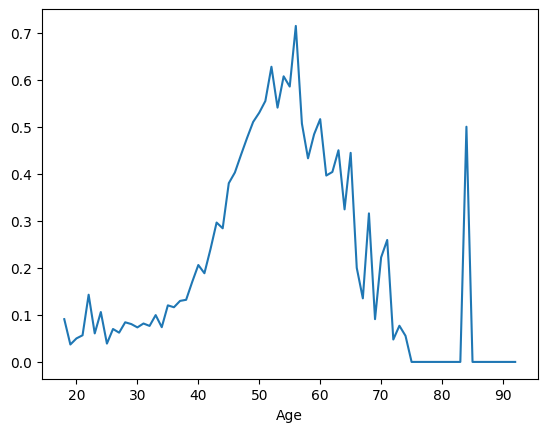

In [51]:
df.groupby("Age")["Exited"].mean().plot()

<Axes: xlabel='Age'>

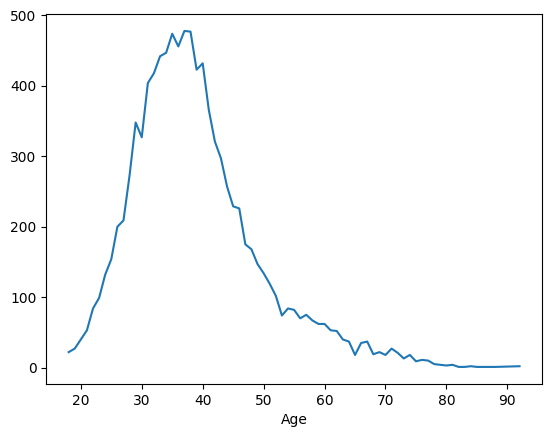

In [52]:
df["Age"].value_counts().sort_index().plot()

<Axes: xlabel='Age'>

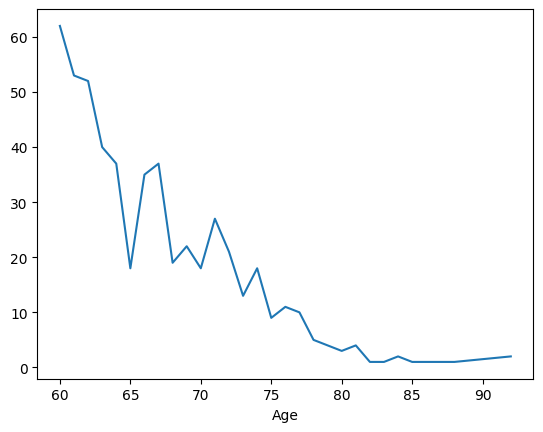

In [53]:
df["Age"].value_counts().sort_index().loc[60:].plot()

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

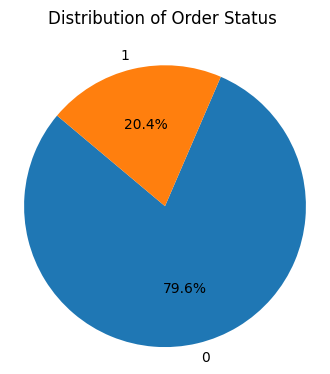

In [55]:
plt.figure(figsize=(4,4))
output_counts = df['Exited'].value_counts()
plt.pie(output_counts, labels=output_counts.index, autopct='%1.1f%%', startangle=140)

plt.axis('equal')
plt.title('Distribution of Order Status \n')
plt.ylabel('')

plt.show()

Box plot for numerical features:


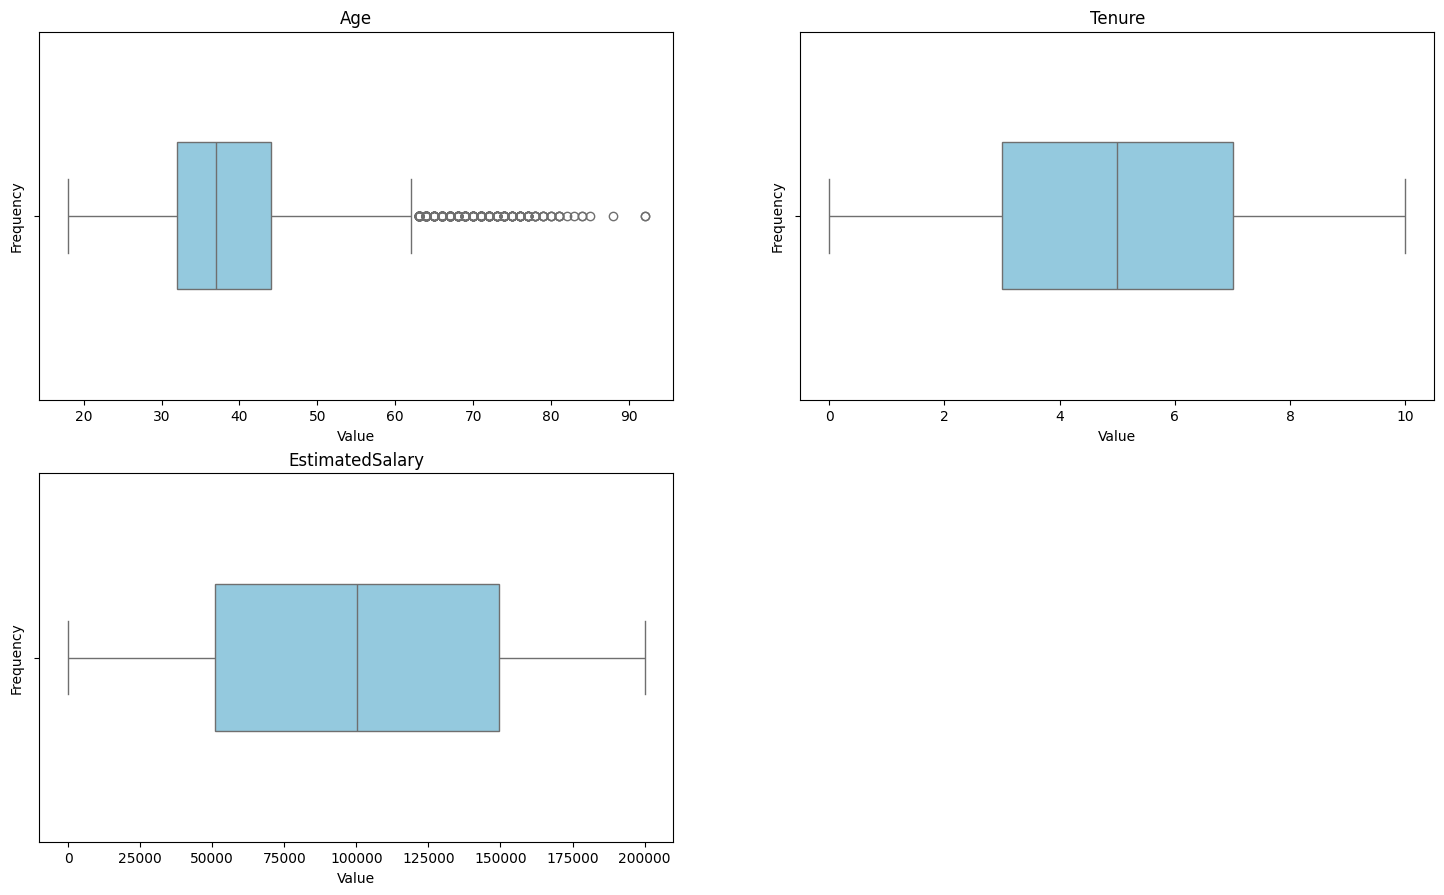

In [57]:
print("Box plot for numerical features:")
plt.figure(figsize=(18,22))
numeric_features = ['Age','Tenure','EstimatedSalary']
for i, column in enumerate(numeric_features):
    plt.subplot(4,2, i + 1)
    sns.boxplot(x=df[column], color='skyblue', width=0.4)
    plt.title(column)
    plt.xlabel('Value')
    plt.ylabel('Frequency')

Count plot for categorical features:


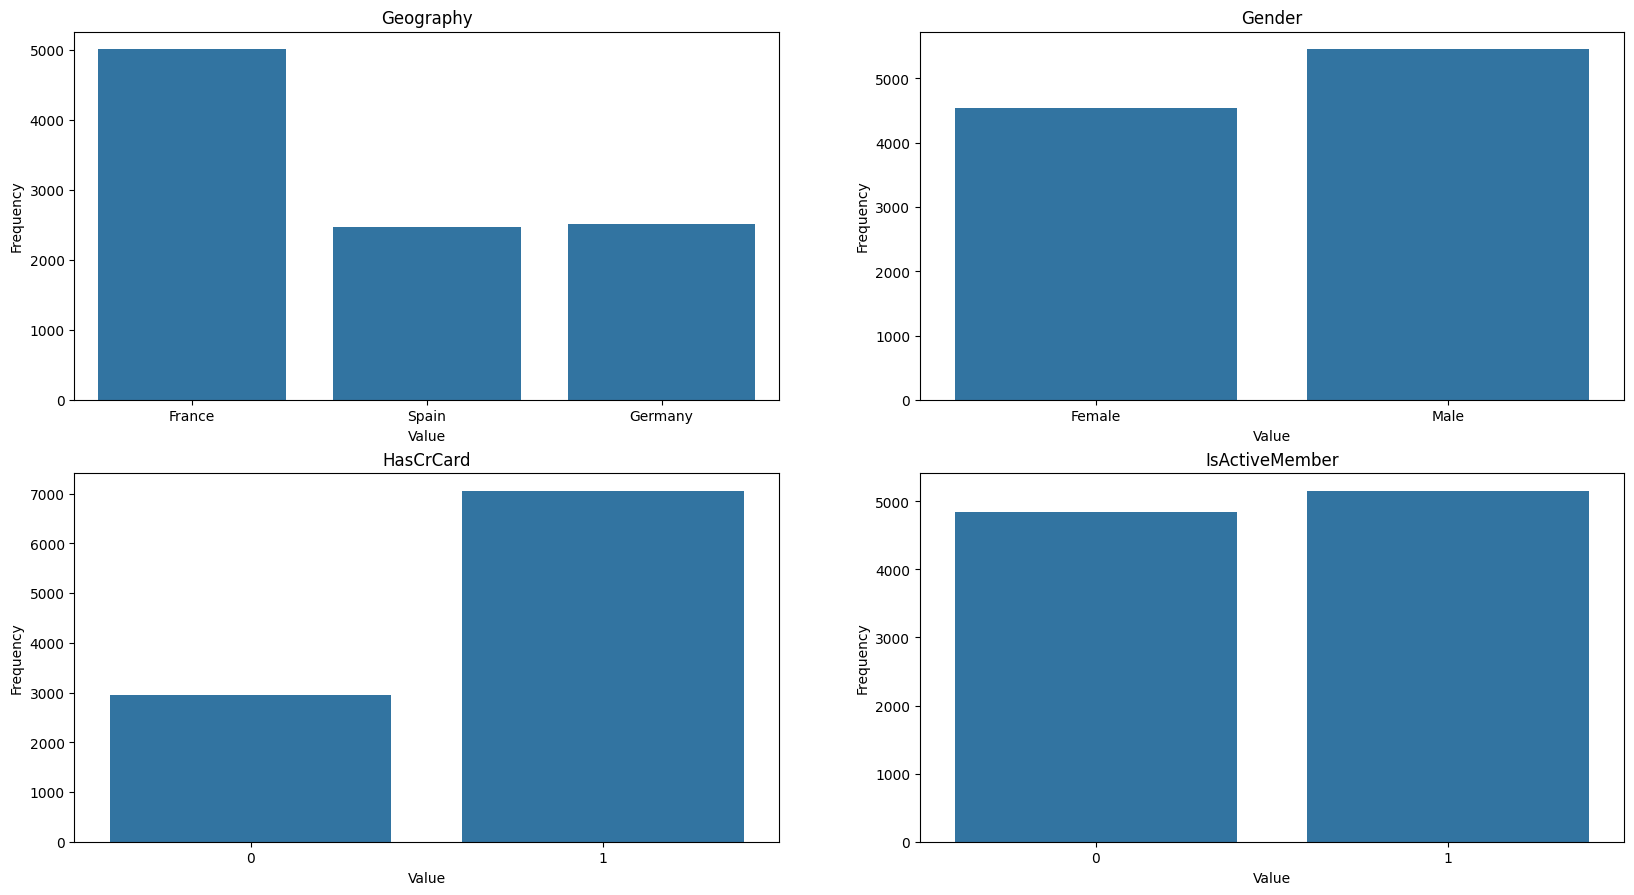

In [58]:
print("Count plot for categorical features:")
plt.figure(figsize=(20,22))

for i, column in enumerate(['Geography','Gender','HasCrCard','IsActiveMember']):
    plt.subplot(4,2,i + 1)
    sns.countplot(x = df[column], data=df)
    plt.title(column)
    plt.xlabel('Value')
    plt.ylabel('Frequency')


Observing independent variables based on the Exited Column:


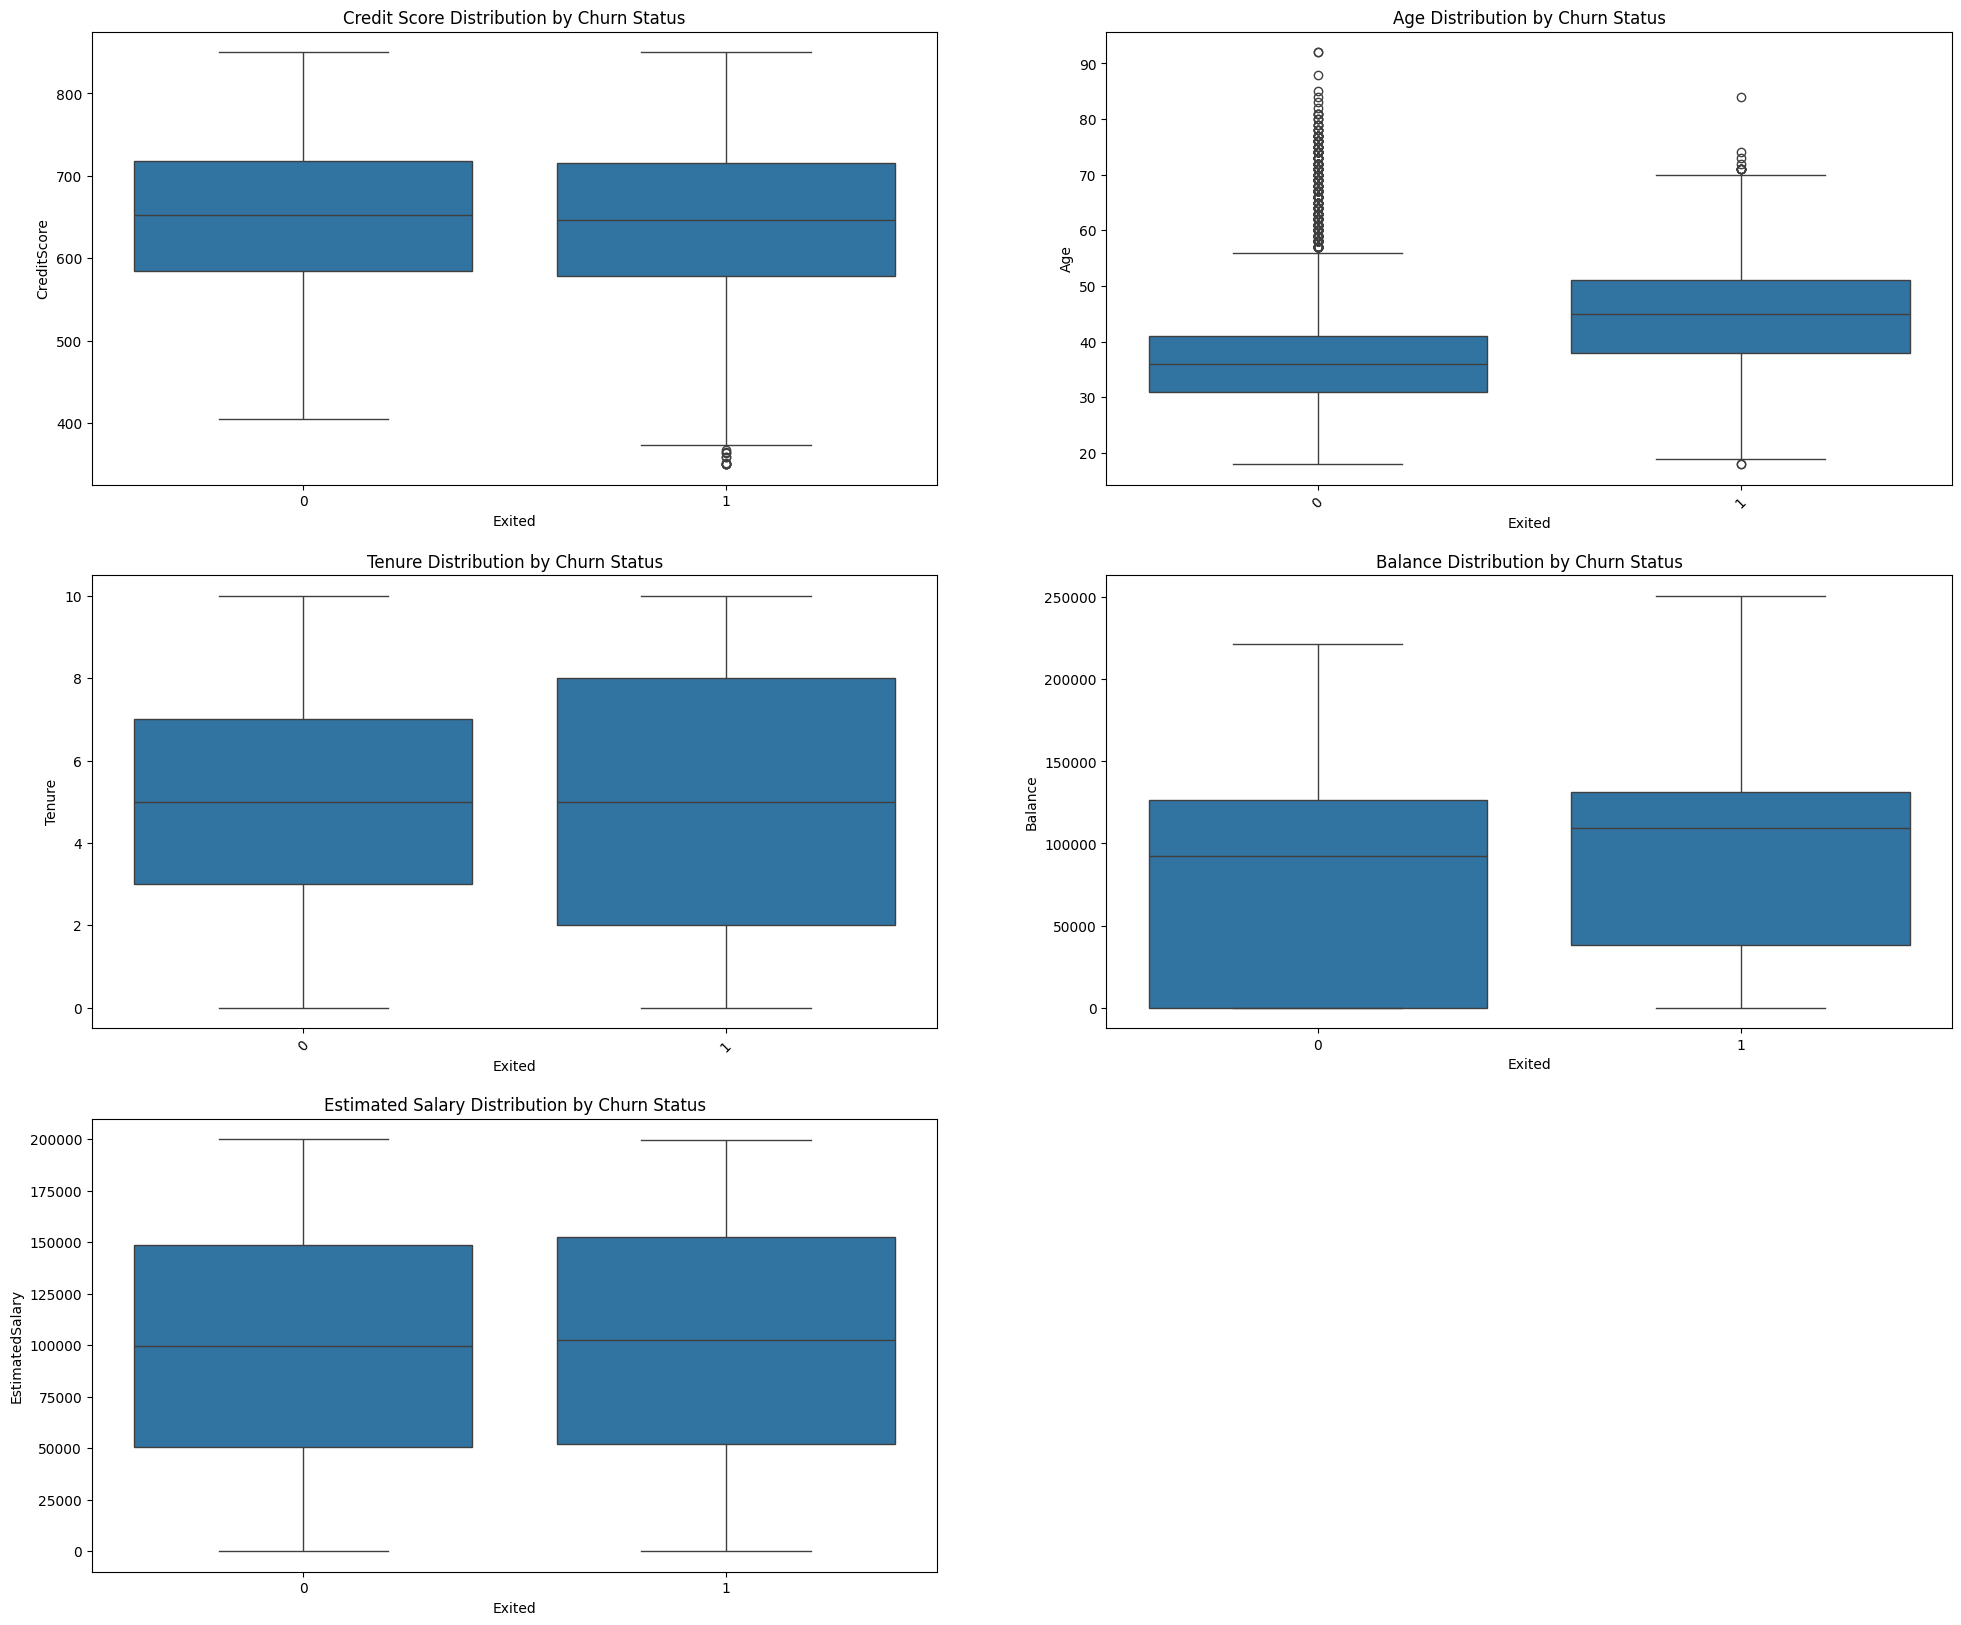

In [59]:

print("Observing independent variables based on the Exited Column:")

fig, axes = plt.subplots(3,2, figsize=(24,20))

sns.boxplot(data=df, y='CreditScore', x ='Exited',  ax=axes[0,0])
axes[0,0].set_title('Credit Score Distribution by Churn Status')

sns.boxplot(data=df, y='Age', x ='Exited', ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Churn Status')
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, y='Tenure', x ='Exited', ax=axes[1,0])
axes[1,0].set_title('Tenure Distribution by Churn Status')
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, y='Balance', x ='Exited', ax=axes[1,1])
axes[1,1].set_title('Balance Distribution by Churn Status')

sns.boxplot(data=df, y='EstimatedSalary', x= 'Exited', ax=axes[2,0])
axes[2,0].set_title('Estimated Salary Distribution by Churn Status')

axes[2,1].axis('off')
plt.show()


In [66]:
df["has_balance"] = (df["Balance"] > 0).astype(int)

df['CreditUtilization']=df['Balance']/df['CreditScore']

df['InteractionScore']=df['NumOfProducts']+df['HasCrCard']+df['IsActiveMember']

df['BalanceToSalaryRatio']=df['Balance']/df['EstimatedSalary']

df['CreditScoreAgeInteraction']=df['CreditScore']*df['Age']

<Axes: xlabel='InteractionScore'>

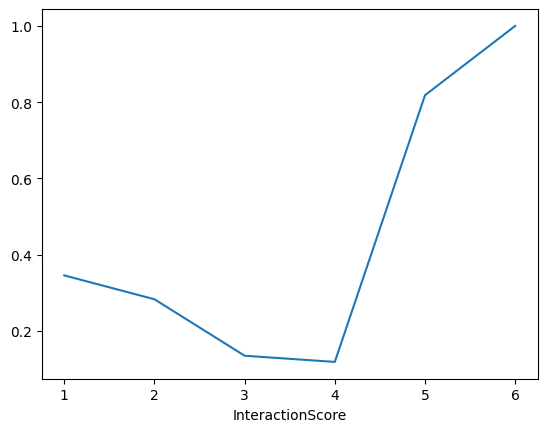

In [68]:
df.groupby("InteractionScore")["Exited"].mean().plot()

In [82]:
df["util_bin"] = pd.qcut(df.loc[df["CreditUtilization"] > 0, "CreditUtilization"], 10)

df["util_bin"] = df["util_bin"].cat.add_categories("zero")

df.loc[df["CreditUtilization"] == 0, "util_bin"] = "zero"
df.groupby("util_bin")["Exited"].agg(['mean', 'count'])

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/1371491694.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("util_bin")["Exited"].agg(['mean', 'count'])


,mean,count
util_bin,,
"(5.004, 121.521]",0.217527,639
"(121.521, 141.58]",0.206897,638
"(141.58, 156.88]",0.236677,638
"(156.88, 170.441]",0.236677,638
"(170.441, 183.368]",0.226917,639
"(183.368, 198.214]",0.272727,638
"(198.214, 213.918]",0.253918,638
"(213.918, 233.275]",0.246082,638
"(233.275, 260.71]",0.235110,638


<Axes: xlabel='NumOfProducts'>

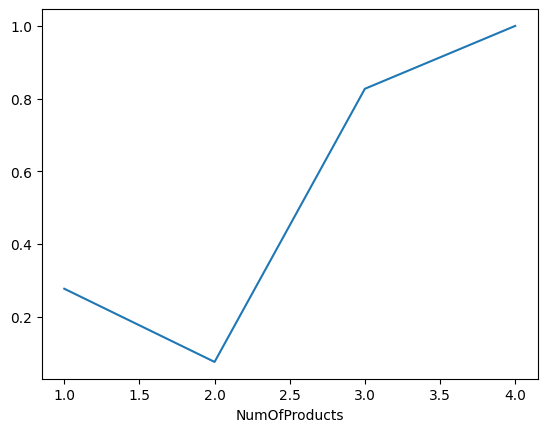

In [72]:
df.groupby("NumOfProducts")["Exited"].mean().sort_index().plot()

In [ ]:
Wrapping up

In [83]:
df.groupby("IsActiveMember")["Exited"].mean()

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/1082259664.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["Age"], 4))["Exited"].mean()


Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/1046611995.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("util_bin")["Exited"].mean().plot(kind="bar")


<Axes: xlabel='util_bin'>

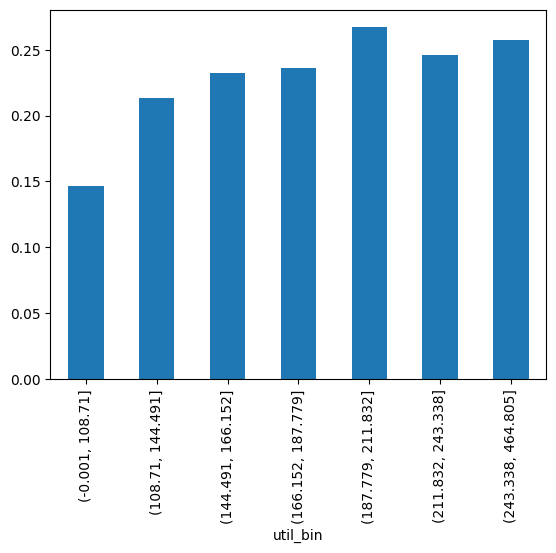

In [93]:
df["util_bin"] = pd.qcut(df["CreditUtilization"], 10, duplicates='drop')

df.groupby("util_bin")["Exited"].mean().plot(kind="bar")
#df.groupby("CreditUtilization")["Exited"].mean().sort_index().plot()

In [85]:
df.groupby(pd.qcut(df["Age"], 4))["Exited"].mean()

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/1485624299.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["Age"], 4))["Exited"].mean()


Age
(17.999, 32.0]    0.076344
(32.0, 37.0]      0.108402
(37.0, 44.0]      0.206374
(44.0, 92.0]      0.446154
Name: Exited, dtype: float64

In [89]:
#df.groupby((df["Balance"] > 0))["Exited"].mean()
df.groupby(pd.qcut(df["Balance"], 9, duplicates="drop"))["Exited"].mean()

/var/folders/0n/p82f15m5287_nlztl93bdtn80000gn/T/ipykernel_94273/2946277525.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["Balance"], 9, duplicates="drop"))["Exited"].mean()


Balance
(-0.001, 86055.17]        0.149831
(86055.17, 104848.68]     0.216922
(104848.68, 118100.59]    0.284428
(118100.59, 130812.91]    0.261926
(130812.91, 147307.91]    0.238524
(147307.91, 250898.09]    0.232223
Name: Exited, dtype: float64

In [90]:
df.groupby("IsActiveMember")["Exited"].mean()

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

In [ ]:
### OBSERVATION:

"""
    1-German customers have a visibly higher likelihood of churn.
    2-Churn rate and Age have a positive correlation, meaning older customers are more likely to churn.
    3-Also, churn increases as balance rises from low to medium, however it drops and stabilises when we look at higher balances. This mean, low churn is negatively correlated with churn whereas churn rises as balance rises. However no such correlatrion exists for high balances.
    4-We can also see active members are less likely to churn.
    5-Finally, high CreditUtilization(df['Balance']/df['CreditScore']) is in positive correlation with churn rate.
                                                                                                                                        """
